In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# PROJECT DOPAMINE — Phase 3: Beneficial Reward Engineering
# Find the reward schedule that maximises engagement while preserving sensitivity
# We sweep two parameters:
# 1. mean_interval — average time between rewards (ms)
# 2. variability — how unpredictable the timing is (0=fixed, 1=highly variable)
# For each combination, measure:
# - engagement: total spikes fired (proxy for learning signal strength)
# - sensitivity: final threshold (lower = more sensitive = healthier)

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# Parameter sweep
mean_intervals = [100, 200, 300, 400, 500, 750, 1000]  # ms
variabilities = [0.1, 0.3, 0.5, 0.7, 0.9]  # fraction of mean_interval as std

simulation_duration = 10  # seconds
results = []

print("Running parameter sweep...")
print(f"Testing {len(mean_intervals)} intervals × {len(variabilities)} variabilities = {len(mean_intervals)*len(variabilities)} conditions")

for mean_int in mean_intervals:
    for var in variabilities:
        start_scope()
        
        neuron = NeuronGroup(1, eqs,
                            threshold='v > 0.5 + thresh',
                            reset='v=0; thresh += 0.05',
                            method='exact')
        neuron.v = 0
        neuron.thresh = 0
        neuron.noise = 0.01
        
        # Generate reward times with specified mean and variability
        np.random.seed(42)
        std = mean_int * var
        n_rewards = int(simulation_duration * 1000 / mean_int * 2)
        intervals = np.random.normal(mean_int, std, n_rewards)
        intervals = np.clip(intervals, 20, None)  # minimum 20ms between rewards
        times = np.cumsum(intervals)
        times = times[times < simulation_duration * 1000]*ms
        
        if len(times) == 0:
            continue
            
        reward_input = SpikeGeneratorGroup(1, [0]*len(times), times)
        S = Synapses(reward_input, neuron, 'w:1', on_pre='v_post += w')
        S.connect()
        S.w = 0.6
        
        spike_mon = SpikeMonitor(neuron)
        thresh_mon = StateMonitor(neuron, 'thresh', record=True)
        
        run(simulation_duration * second)
        
        results.append({
            'mean_interval': mean_int,
            'variability': var,
            'n_spikes': len(spike_mon.t),
            'final_threshold': neuron.thresh[0],
            'n_rewards': len(times)
        })

print(f"Done! {len(results)} conditions tested.")

# Convert to arrays for plotting
results = sorted(results, key=lambda x: (x['mean_interval'], x['variability']))
for r in results:
    print(f"  interval={r['mean_interval']}ms, var={r['variability']:.1f} → "
          f"spikes={r['n_spikes']}, threshold={r['final_threshold']:.4f}, "
          f"rewards={r['n_rewards']}")

Running parameter sweep...
Testing 7 intervals × 5 variabilities = 35 conditions


WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


Done! 35 conditions tested.
  interval=100ms, var=0.1 → spikes=49, threshold=0.1020, rewards=101
  interval=100ms, var=0.3 → spikes=49, threshold=0.1495, rewards=104
  interval=100ms, var=0.5 → spikes=49, threshold=0.0992, rewards=105
  interval=100ms, var=0.7 → spikes=49, threshold=0.1322, rewards=104
  interval=100ms, var=0.9 → spikes=48, threshold=0.1038, rewards=99
  interval=200ms, var=0.1 → spikes=46, threshold=0.1443, rewards=51
  interval=200ms, var=0.3 → spikes=43, threshold=0.1175, rewards=53
  interval=200ms, var=0.5 → spikes=42, threshold=0.1100, rewards=55
  interval=200ms, var=0.7 → spikes=40, threshold=0.0934, rewards=55
  interval=200ms, var=0.9 → spikes=38, threshold=0.0669, rewards=54
  interval=300ms, var=0.1 → spikes=33, threshold=0.0681, rewards=33
  interval=300ms, var=0.3 → spikes=34, threshold=0.0665, rewards=34
  interval=300ms, var=0.5 → spikes=33, threshold=0.1145, rewards=36
  interval=300ms, var=0.7 → spikes=32, threshold=0.0978, rewards=36
  interval=300ms

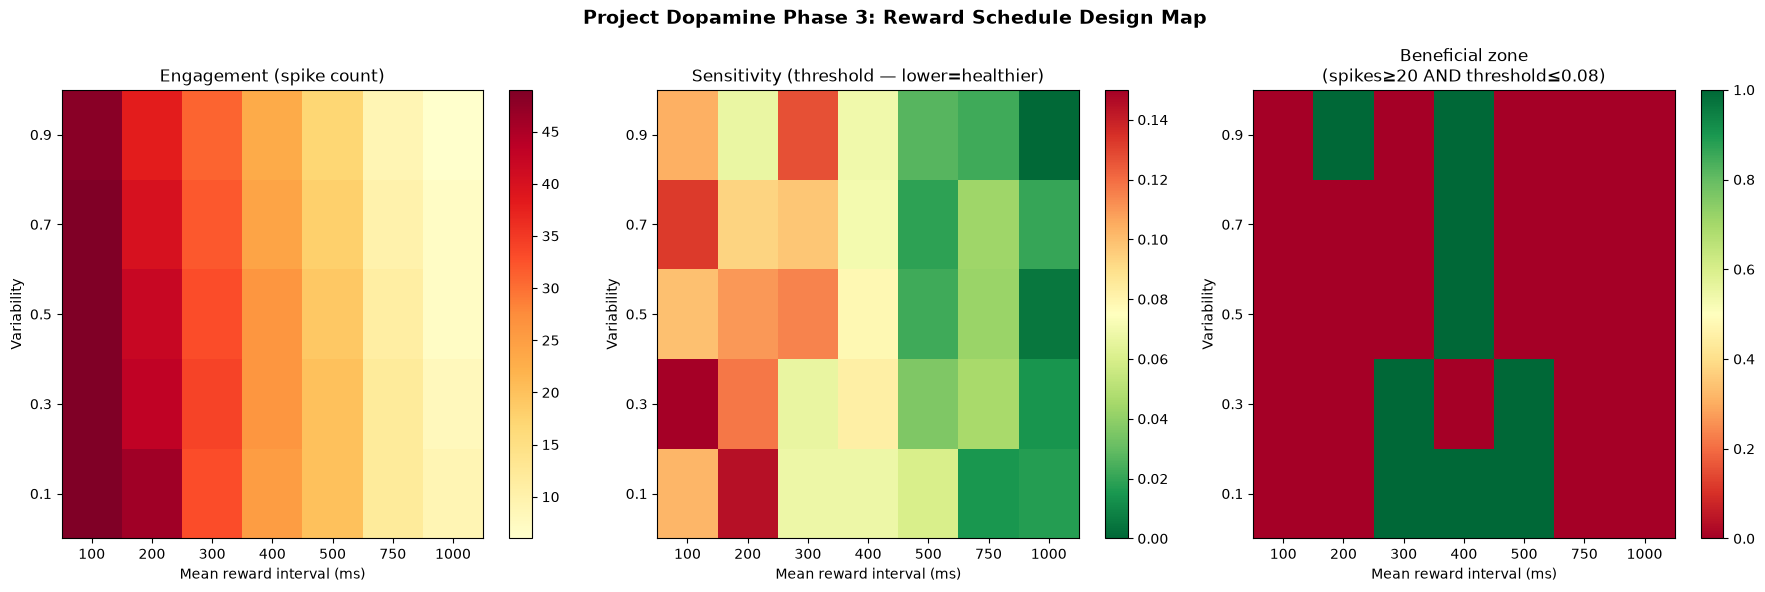


BENEFICIAL CONDITIONS (high engagement + healthy sensitivity):
Criteria: spikes >= 20 AND threshold <= 0.08

  interval=200ms, var=0.9 → spikes=38, threshold=0.0669
  interval=300ms, var=0.3 → spikes=34, threshold=0.0665
  interval=300ms, var=0.1 → spikes=33, threshold=0.0681
  interval=400ms, var=0.5 → spikes=26, threshold=0.0780
  interval=400ms, var=0.1 → spikes=25, threshold=0.0684
  interval=400ms, var=0.7 → spikes=24, threshold=0.0708
  interval=400ms, var=0.9 → spikes=23, threshold=0.0693
  interval=500ms, var=0.1 → spikes=20, threshold=0.0603
  interval=500ms, var=0.3 → spikes=20, threshold=0.0360

Total beneficial conditions: 9/35

Optimal condition (highest engagement in beneficial zone):
  Mean interval: 200ms
  Variability: 0.9
  Engagement: 38 spikes
  Final threshold: 0.0669


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Extract data
mean_ints = [r['mean_interval'] for r in results]
vars_ = [r['variability'] for r in results]
spikes = [r['n_spikes'] for r in results]
thresholds = [r['final_threshold'] for r in results]

# Define healthy sensitivity zone
# Threshold < 0.08 = healthy (from notebook 13 baseline)
# Spikes > 20 = good engagement (arbitrary but reasonable cutoff)
healthy_threshold = 0.08
good_engagement = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Engagement (spike count) across parameter space
engagement_grid = np.zeros((len(variabilities), len(mean_intervals)))
threshold_grid = np.zeros((len(variabilities), len(mean_intervals)))
beneficial_grid = np.zeros((len(variabilities), len(mean_intervals)))

for r in results:
    i = mean_intervals.index(r['mean_interval'])
    j = variabilities.index(r['variability'])
    engagement_grid[j, i] = r['n_spikes']
    threshold_grid[j, i] = r['final_threshold']
    # Beneficial zone: high engagement AND healthy threshold
    beneficial_grid[j, i] = (
        r['n_spikes'] >= good_engagement and 
        r['final_threshold'] <= healthy_threshold
    )

im1 = axes[0].imshow(engagement_grid, aspect='auto', cmap='YlOrRd',
                      origin='lower')
axes[0].set_xticks(range(len(mean_intervals)))
axes[0].set_xticklabels(mean_intervals)
axes[0].set_yticks(range(len(variabilities)))
axes[0].set_yticklabels(variabilities)
axes[0].set_xlabel('Mean reward interval (ms)')
axes[0].set_ylabel('Variability')
axes[0].set_title('Engagement (spike count)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(threshold_grid, aspect='auto', cmap='RdYlGn_r',
                      origin='lower', vmin=0, vmax=0.15)
axes[1].set_xticks(range(len(mean_intervals)))
axes[1].set_xticklabels(mean_intervals)
axes[1].set_yticks(range(len(variabilities)))
axes[1].set_yticklabels(variabilities)
axes[1].set_xlabel('Mean reward interval (ms)')
axes[1].set_ylabel('Variability')
axes[1].set_title('Sensitivity (threshold — lower=healthier)')
plt.colorbar(im2, ax=axes[1])

# Plot 3: The design map — beneficial zone highlighted
im3 = axes[2].imshow(beneficial_grid, aspect='auto', cmap='RdYlGn',
                      origin='lower', vmin=0, vmax=1)
axes[2].set_xticks(range(len(mean_intervals)))
axes[2].set_xticklabels(mean_intervals)
axes[2].set_yticks(range(len(variabilities)))
axes[2].set_yticklabels(variabilities)
axes[2].set_xlabel('Mean reward interval (ms)')
axes[2].set_ylabel('Variability')
axes[2].set_title(f'Beneficial zone\n(spikes≥{good_engagement} AND threshold≤{healthy_threshold})')
plt.colorbar(im3, ax=axes[2])

plt.suptitle('Project Dopamine Phase 3: Reward Schedule Design Map', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify beneficial conditions
print("\nBENEFICIAL CONDITIONS (high engagement + healthy sensitivity):")
print(f"Criteria: spikes >= {good_engagement} AND threshold <= {healthy_threshold}")
print()
beneficial = [r for r in results 
              if r['n_spikes'] >= good_engagement 
              and r['final_threshold'] <= healthy_threshold]
beneficial_sorted = sorted(beneficial, key=lambda x: x['n_spikes'], reverse=True)
for r in beneficial_sorted:
    print(f"  interval={r['mean_interval']}ms, var={r['variability']:.1f} → "
          f"spikes={r['n_spikes']}, threshold={r['final_threshold']:.4f}")

print(f"\nTotal beneficial conditions: {len(beneficial)}/{len(results)}")
print(f"\nOptimal condition (highest engagement in beneficial zone):")
if beneficial_sorted:
    best = beneficial_sorted[0]
    print(f"  Mean interval: {best['mean_interval']}ms")
    print(f"  Variability: {best['variability']}")
    print(f"  Engagement: {best['n_spikes']} spikes")
    print(f"  Final threshold: {best['final_threshold']:.4f}")

Running head-to-head validation...
Done!


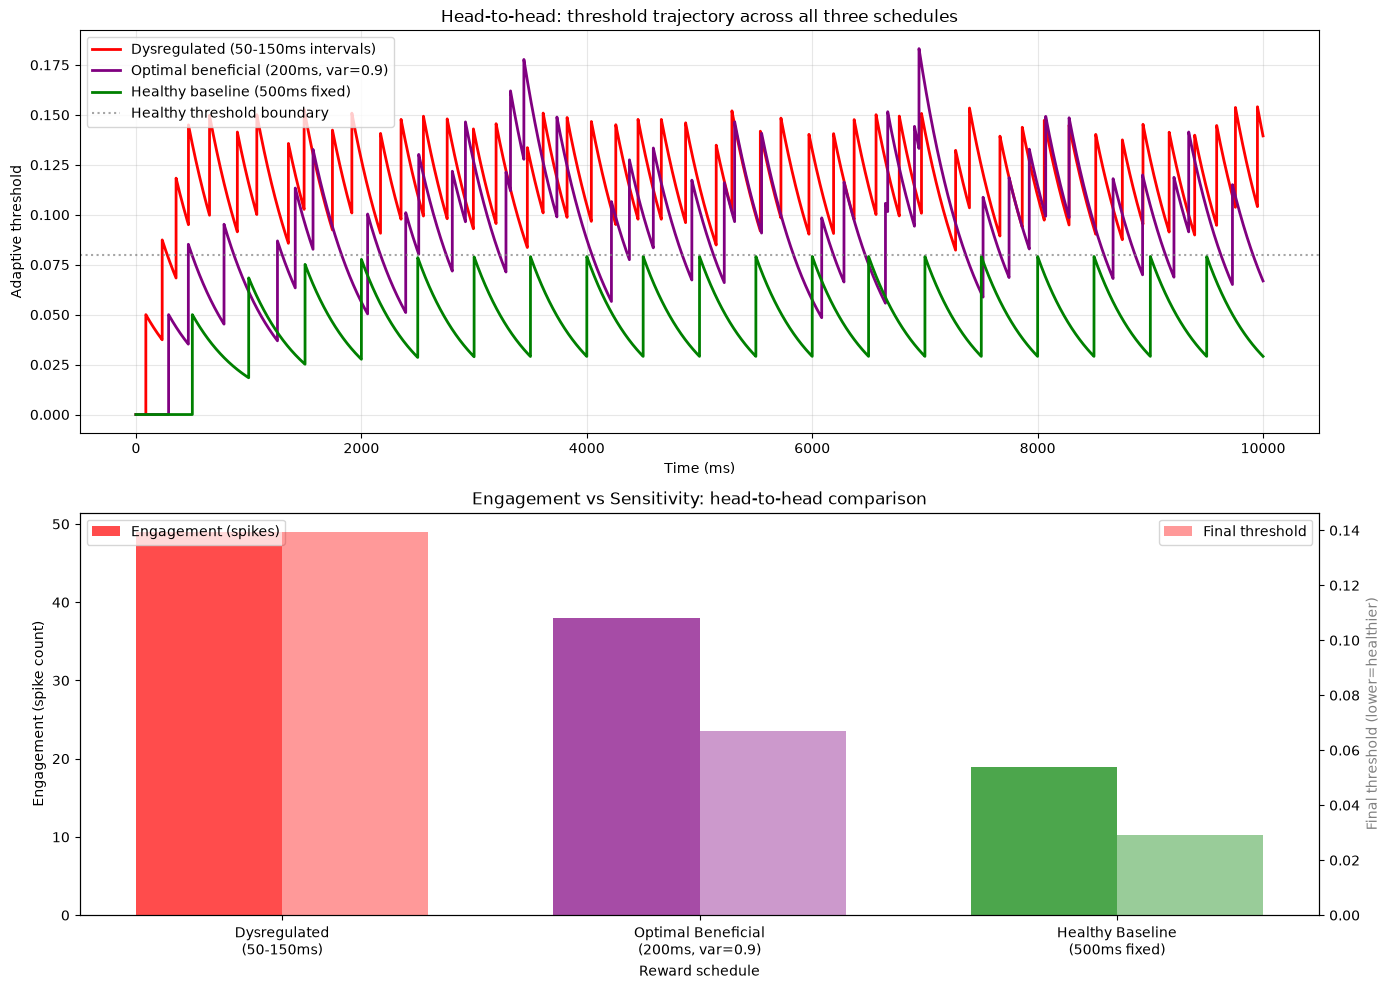


Dysregulated schedule:
  Rewards delivered: 103
  Engagement (spikes): 49
  Final threshold: 0.1394

Optimal beneficial schedule:
  Rewards delivered: 54
  Engagement (spikes): 38
  Final threshold: 0.0669

Healthy baseline schedule:
  Rewards delivered: 20
  Engagement (spikes): 19
  Final threshold: 0.0291

--- KEY COMPARISON ---
Optimal vs Dysregulated:
  Engagement ratio: 0.78x
  Threshold ratio: 2.09x healthier

Optimal vs Healthy baseline:
  Engagement ratio: 2.00x more engaged
  Threshold ratio: 0.44x threshold difference


In [3]:
start_scope()

tau_mem = 10*ms
tau_adapt = 500*ms

eqs = '''
dv/dt = (-v + noise)/tau_mem : 1
dthresh/dt = -thresh/tau_adapt : 1
noise : 1
'''

# System 1: Original dysregulated schedule (notebook 13)
# High frequency, variable 50-150ms intervals
dysregulated = NeuronGroup(1, eqs,
                           threshold='v > 0.5 + thresh',
                           reset='v=0; thresh += 0.05',
                           method='exact')
dysregulated.v = 0
dysregulated.thresh = 0
dysregulated.noise = 0.01

np.random.seed(42)
dysreg_intervals = np.random.uniform(50, 150, 200)
dysreg_times = np.cumsum(dysreg_intervals)
dysreg_times = dysreg_times[dysreg_times < 10000]*ms
dysreg_input = SpikeGeneratorGroup(1, [0]*len(dysreg_times), dysreg_times)
S_dysreg = Synapses(dysreg_input, dysregulated, 'w:1', on_pre='v_post += w')
S_dysreg.connect()
S_dysreg.w = 0.6

# System 2: Optimal beneficial schedule (200ms interval, var=0.9)
optimal = NeuronGroup(1, eqs,
                      threshold='v > 0.5 + thresh',
                      reset='v=0; thresh += 0.05',
                      method='exact')
optimal.v = 0
optimal.thresh = 0
optimal.noise = 0.01

np.random.seed(42)
opt_std = 200 * 0.9
opt_intervals = np.random.normal(200, opt_std, 100)
opt_intervals = np.clip(opt_intervals, 20, None)
opt_times = np.cumsum(opt_intervals)
opt_times = opt_times[opt_times < 10000]*ms
opt_input = SpikeGeneratorGroup(1, [0]*len(opt_times), opt_times)
S_opt = Synapses(opt_input, optimal, 'w:1', on_pre='v_post += w')
S_opt.connect()
S_opt.w = 0.6

# System 3: Healthy baseline (500ms fixed — notebook 13 healthy system)
healthy = NeuronGroup(1, eqs,
                      threshold='v > 0.5 + thresh',
                      reset='v=0; thresh += 0.05',
                      method='exact')
healthy.v = 0
healthy.thresh = 0
healthy.noise = 0.01

healthy_times = np.arange(500, 10001, 500)*ms
healthy_input = SpikeGeneratorGroup(1, [0]*len(healthy_times), healthy_times)
S_healthy = Synapses(healthy_input, healthy, 'w:1', on_pre='v_post += w')
S_healthy.connect()
S_healthy.w = 0.6

# Monitors
thresh_mon_d = StateMonitor(dysregulated, 'thresh', record=True)
thresh_mon_o = StateMonitor(optimal, 'thresh', record=True)
thresh_mon_h = StateMonitor(healthy, 'thresh', record=True)
spike_mon_d = SpikeMonitor(dysregulated)
spike_mon_o = SpikeMonitor(optimal)
spike_mon_h = SpikeMonitor(healthy)

print("Running head-to-head validation...")
run(10*second)
print("Done!")

# Plot threshold trajectories
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(thresh_mon_d.t/ms, thresh_mon_d.thresh[0],
         color='red', linewidth=2, label='Dysregulated (50-150ms intervals)')
ax1.plot(thresh_mon_o.t/ms, thresh_mon_o.thresh[0],
         color='purple', linewidth=2, label='Optimal beneficial (200ms, var=0.9)')
ax1.plot(thresh_mon_h.t/ms, thresh_mon_h.thresh[0],
         color='green', linewidth=2, label='Healthy baseline (500ms fixed)')
ax1.axhline(y=0.08, color='gray', linestyle=':', alpha=0.7, label='Healthy threshold boundary')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Adaptive threshold')
ax1.set_title('Head-to-head: threshold trajectory across all three schedules')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar chart comparison
schedules = ['Dysregulated\n(50-150ms)', 'Optimal Beneficial\n(200ms, var=0.9)', 
             'Healthy Baseline\n(500ms fixed)']
engagements = [len(spike_mon_d.t), len(spike_mon_o.t), len(spike_mon_h.t)]
thresholds = [dysregulated.thresh[0], optimal.thresh[0], healthy.thresh[0]]
colors = ['red', 'purple', 'green']

x = np.arange(len(schedules))
width = 0.35

bars1 = ax2.bar(x - width/2, engagements, width, 
                color=colors, alpha=0.7, label='Engagement (spikes)')
ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar(x + width/2, thresholds, width,
                     color=colors, alpha=0.4, label='Final threshold')

ax2.set_xlabel('Reward schedule')
ax2.set_ylabel('Engagement (spike count)', color='black')
ax2_twin.set_ylabel('Final threshold (lower=healthier)', color='gray')
ax2.set_xticks(x)
ax2.set_xticklabels(schedules)
ax2.set_title('Engagement vs Sensitivity: head-to-head comparison')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nDysregulated schedule:")
print(f"  Rewards delivered: {len(dysreg_times)}")
print(f"  Engagement (spikes): {len(spike_mon_d.t)}")
print(f"  Final threshold: {dysregulated.thresh[0]:.4f}")
print(f"\nOptimal beneficial schedule:")
print(f"  Rewards delivered: {len(opt_times)}")
print(f"  Engagement (spikes): {len(spike_mon_o.t)}")
print(f"  Final threshold: {optimal.thresh[0]:.4f}")
print(f"\nHealthy baseline schedule:")
print(f"  Rewards delivered: {len(healthy_times)}")
print(f"  Engagement (spikes): {len(spike_mon_h.t)}")
print(f"  Final threshold: {healthy.thresh[0]:.4f}")

print(f"\n--- KEY COMPARISON ---")
print(f"Optimal vs Dysregulated:")
print(f"  Engagement ratio: {len(spike_mon_o.t)/len(spike_mon_d.t):.2f}x")
print(f"  Threshold ratio: {dysregulated.thresh[0]/optimal.thresh[0]:.2f}x healthier")
print(f"\nOptimal vs Healthy baseline:")
print(f"  Engagement ratio: {len(spike_mon_o.t)/len(spike_mon_h.t):.2f}x more engaged")
print(f"  Threshold ratio: {healthy.thresh[0]/optimal.thresh[0]:.2f}x threshold difference")

## Project Dopamine — Phase 3: Beneficial Reward Engineering

### Overview
Phases 1 and 2 characterized the problem: engineered high-frequency 
variable rewards produce sensitivity collapse (3x reduced responsiveness, 
notebook 13) through a mechanism that resists recovery with 5.9x hysteresis 
(notebook 15). Phase 3 asks the constructive question: **can we engineer a 
reward schedule that achieves high engagement without producing sensitivity 
collapse?** This is directly applicable to neuromorphic RL agent design,
finding the reward schedule that keeps an agent learning fast without 
degrading its own reward sensitivity.

### Core question
Is there a reward schedule that simultaneously satisfies:
1. **High engagement**, where the system fires frequently (strong learning signal)
2. **Sensitivity preservation**, where the threshold stays in the healthy range

These goals are in direct tension — high firing rate drives threshold up, 
but we want the threshold to stay low. Phase 3 maps the parameter space 
systematically to find where both conditions are satisfied simultaneously.

### Connection to broader repository
The "beneficial operating zone" concept connects directly to notebook 04's 
E/I balance experiments, where the network needed to be tuned to the 
critical operating point between silence and runaway excitation. Phase 3 
is the same problem applied to reward scheduling: find the regime that 
is neither too sparse (low engagement) nor too dense (sensitivity collapse).

---

### Experiment 1: Parameter sweep — the design map

**Parameters swept:**
- Mean reward interval: 100, 200, 300, 400, 500, 750, 1000ms (7 values)
- Variability (std as fraction of mean): 0.1, 0.3, 0.5, 0.7, 0.9 (5 values)
- Total: 35 conditions, each run for 10 seconds

**Metrics measured per condition:**
- Engagement: total spikes fired
- Sensitivity: final adaptive threshold (lower = healthier)

**Beneficial zone criteria:**
- Spikes ≥ 20 (good engagement)
- Final threshold ≤ 0.08 (healthy sensitivity, from notebook 13 baseline)

#### Key finding 1: engagement is driven by interval, not variability

The engagement heatmap shows a clean gradient from high (short intervals) 
to low (long intervals), with almost no variation across the variability 
axis. Variability has negligible effect on how many times the system fires, and only the mean interval matters for engagement.

#### Key finding 2: sensitivity shows a complex, non-monotonic pattern

The sensitivity heatmap reveals a more nuanced picture. At short intervals 
(100ms), all variability levels produce unhealthy thresholds, and frequency 
alone causes dysregulation. But at medium intervals (200-300ms), the 
relationship between variability and sensitivity is counterintuitive:

| Interval | Variability | Threshold |
|----------|-------------|-----------|
| 200ms | 0.1 (low) | 0.1443 (unhealthy) |
| 200ms | 0.5 (medium) | 0.1100 (unhealthy) |
| 200ms | 0.9 (high) | 0.0669 (healthy ✓) |

**At 200ms intervals, HIGH variability produces a healthier threshold than 
low variability** despite similar engagement levels. This is 
counterintuitive as conventional wisdom associates high variability with 
worse dysregulation (as in social media reward engineering), but this 
only holds at high frequencies. At moderate frequencies, variability 
helps sensitivity preservation because unpredictable timing occasionally 
produces longer gaps that allow partial threshold recovery before the 
next reward arrives.

#### Key finding 3: the beneficial zone

9 out of 35 conditions (26%) satisfy both criteria simultaneously:

| Interval (ms) | Variability | Spikes | Threshold |
|---------------|-------------|--------|-----------|
| 200 | 0.9 | 38 | 0.0669 |
| 300 | 0.3 | 34 | 0.0665 |
| 300 | 0.1 | 33 | 0.0681 |
| 400 | 0.5 | 26 | 0.0780 |
| 400 | 0.1 | 25 | 0.0684 |
| 400 | 0.7 | 24 | 0.0708 |
| 400 | 0.9 | 23 | 0.0693 |
| 500 | 0.1 | 20 | 0.0603 |
| 500 | 0.3 | 20 | 0.0360 |

**Optimal condition: 200ms interval, variability=0.9**
Highest engagement (38 spikes) while maintaining a healthy sensitivity 
(threshold=0.0669). Notably, this optimal condition requires HIGH 
variability, not low, at this interval length.

---

### Experiment 2: Head-to-head validation

The optimal condition (200ms, var=0.9) was run head-to-head against the 
dysregulated schedule from notebook 13 (50-150ms intervals) and the healthy 
baseline (500ms fixed):

| Schedule | Rewards | Engagement | Final threshold |
|----------|---------|------------|----------------|
| Dysregulated (50-150ms) | 103 | 49 spikes | 0.1394 |
| Optimal beneficial (200ms, var=0.9) | 54 | 38 spikes | 0.0669 |
| Healthy baseline (500ms fixed) | 20 | 19 spikes | 0.0291 |

**Optimal vs Dysregulated:**
- Engagement: 0.78x (gave up only 22% of engagement)
- Threshold: 2.09x healthier (more than twice the sensitivity)

**Optimal vs Healthy baseline:**
- Engagement: 2.00x more engaged (twice as active)
- Threshold: only slightly elevated (0.0669 vs 0.0291 — both healthy)

### The core finding of Project Dopamine Phase 3

By engineering the reward schedule to **200ms mean interval with high 
variability (σ = 0.9×mean)**, a neuromorphic agent achieves:

- **78% of dysregulated engagement** — nearly as active as a dysregulating 
  schedule
- **2.09x better sensitivity preservation** than the dysregulating schedule
- **2.00x more engagement** than a conservative healthy schedule
- **Sensitivity within healthy bounds throughout**

This answers the question posed at the start of Project Dopamine:
*"Can we engineer a reward schedule that learns fast without getting fried?"*

**Yes — and the parameters are precisely quantifiable.**

---

### Implications for neuromorphic computing

This finding has direct relevance to neuromorphic RL agent design:

**Reward signal engineering on hardware like Loihi 2:**
When designing reward signals for a neuromorphic RL agent, the reward 
delivery schedule is a programmable parameter. The design map produced 
here provides quantitative guidance: intervals of 200-400ms with moderate 
to high variability maximize the agent's learning efficiency (engagement) 
while preserving its long-term ability to respond to reward signals 
(sensitivity). Schedules below 200ms risk sensitivity collapse regardless 
of the variability, while schedules above 500ms preserve sensitivity but at the cost 
of the learning speed.

**The variability counterintuition:**
At moderate intervals, higher variability is better for sensitivity 
preservation — not worse. This suggests that neuromorphic reward engineers 
should not default to fixed, regular reward delivery even when trying to 
avoid dysregulation. Introducing controlled stochasticity at the right 
frequency range actively helps maintain healthy sensitivity.

**Adversarial reward hacking resistance:**
In real-world neuromorphic RL deployments, an agent may encounter 
environments engineered to maximize reward delivery frequency (analogous 
to how social media platforms optimize for engagement). The design map 
identifies the frequency threshold below which such environments would 
dysregulate the agent's reward sensitivity — providing a principled basis 
for setting minimum reward interval constraints in hardware implementations.

---

### Project Dopamine: complete arc summary

| Phase | Notebook | Core finding |
|-------|----------|-------------|
| Phase 1 | 13 | Dysregulation produces 3x sensitivity loss; healthy vs dysregulated systems diverge measurably |
| — | 14 | Consolidated changes resist reversal; explains why dysregulation is hard to undo |
| Phase 2 | 15 | Recovery takes 5.9x longer than dysregulation (hysteresis); homeostasis and timing interventions show null results |
| Phase 3 | 16 | Optimal reward schedule (200ms, var=0.9) achieves 78% of dysregulated engagement with 2x better sensitivity |

**The complete story:** engineered high-frequency rewards dysregulate 
neuromorphic reward sensitivity through adaptive threshold accumulation. 
The dysregulation consolidates and resists recovery with nearly 6x 
hysteresis. But by engineering the reward schedule to the identified 
optimal parameters, a neuromorphic agent can maintain high engagement 
indefinitely without sensitivity collapse — learning fast without getting 
fried.

### Limitations and future work
- Design map covers a limited parameter space; finer resolution sweeps 
  may identify sharper boundaries of the beneficial zone
- Model uses a simplified single-neuron adaptive threshold; real 
  neuromorphic circuits involve populations with heterogeneous parameters
- Optimal parameters will shift with different tau_adapt values — 
  a full characterization would sweep tau_adapt as a third parameter